In [1]:
import sys
import os


sys.path.append(os.path.abspath(".."))

In [2]:
from src.journal_api import get_papers_dataframe

In [3]:
df = get_papers_dataframe(
    venue="Transactions of the Association for Computational Linguistics",
    fields_of_study="Computer Science",
    publication_types="JournalArticle",
    date_range="2010-01-01:2025-12-31"
)

df.head()

,paperId,title,venue,year,openAccessPdf,publicationDate,authors,abstract,month,four_month_section
0,cd0a1d660771c9d2fa42c9446fbc1f441d40e9d1,A Novel Feature-based Bayesian Model for Query...,Transactions of the Association for Computatio...,2012,{'url': 'http://www.mitpressjournals.org/doi/p...,2012-12-10,"[{'authorId': '2386020789', 'name': 'Jiwei Li'...",Supervised learning methods and LDA based topi...,12,3
1,2ae77bb984dce5af3181a28340d603ad9bb0b9b1,Extensions of Ordering Sets of States from Eff...,Transactions of the Association for Computatio...,2013,{'url': 'https://easychair.org/publications/op...,2013-02-24,"[{'authorId': '102679761', 'name': 'Ji R I Jan...",None,2,1
2,03c605c8b0bdd7ce7e2123ab6394dcc25f70f6a9,Finding Optimal 1-Endpoint-Crossing Trees,Transactions of the Association for Computatio...,2013,{'url': 'http://www.mitpressjournals.org/doi/p...,2013-03-01,"[{'authorId': '2585932', 'name': 'Emily Pitler...",Dependency parsing algorithms capable of produ...,3,1
3,21b3007f967d39e1346bc91e0fc8b3f16121300c,Grounding Action Descriptions in Videos,Transactions of the Association for Computatio...,2013,{'url': 'http://www.mitpressjournals.org/doi/p...,2013-03-31,"[{'authorId': '2485529', 'name': 'Michaela Reg...",Recent work has shown that the integration of ...,3,1
4,22566980b49e2b2d3594f9446f7398da5d344a5c,Branch and Bound Algorithm for Dependency Pars...,Transactions of the Association for Computatio...,2013,{'url': 'http://www.mitpressjournals.org/doi/p...,2013-03-31,"[{'authorId': '2067733840', 'name': 'Xian Qian...",Graph based dependency parsing is inefficient ...,3,1


In [43]:
df.count()

paperId               874
title                 874
venue                 874
year                  874
openAccessPdf         874
publicationDate       843
authors               874
abstract              824
month                 874
four_month_section    874
alignment_score       874
pca1                  874
pca2                  874
dtype: int64

In [4]:
from src.journal_api import get_papers_dataframe

In [5]:
from src.embeddings import EmbeddingModel

embedder = EmbeddingModel()

In [6]:
from src.scoring import compute_similarity, summary_statistics

In [7]:
journal_scope = """
This journal publishes research in computational linguistics,
natural language processing, machine learning for language understanding,
syntax, semantics, discourse, multilingual NLP, and language generation.
"""

In [8]:
scope_embedding = embedder.encode_text(journal_scope)

article_embeddings = embedder.encode_list(
    df["abstract"].fillna("").tolist()
)

Batches:   0%|          | 0/28 [00:00<?, ?it/s]

In [9]:
scores = compute_similarity(article_embeddings, scope_embedding)

df["alignment_score"] = scores
df.head()

,paperId,title,venue,year,openAccessPdf,publicationDate,authors,abstract,month,four_month_section,alignment_score
0,cd0a1d660771c9d2fa42c9446fbc1f441d40e9d1,A Novel Feature-based Bayesian Model for Query...,Transactions of the Association for Computatio...,2012,{'url': 'http://www.mitpressjournals.org/doi/p...,2012-12-10,"[{'authorId': '2386020789', 'name': 'Jiwei Li'...",Supervised learning methods and LDA based topi...,12,3,0.325082
1,2ae77bb984dce5af3181a28340d603ad9bb0b9b1,Extensions of Ordering Sets of States from Eff...,Transactions of the Association for Computatio...,2013,{'url': 'https://easychair.org/publications/op...,2013-02-24,"[{'authorId': '102679761', 'name': 'Ji R I Jan...",None,2,1,0.110379
2,03c605c8b0bdd7ce7e2123ab6394dcc25f70f6a9,Finding Optimal 1-Endpoint-Crossing Trees,Transactions of the Association for Computatio...,2013,{'url': 'http://www.mitpressjournals.org/doi/p...,2013-03-01,"[{'authorId': '2585932', 'name': 'Emily Pitler...",Dependency parsing algorithms capable of produ...,3,1,0.459423
3,21b3007f967d39e1346bc91e0fc8b3f16121300c,Grounding Action Descriptions in Videos,Transactions of the Association for Computatio...,2013,{'url': 'http://www.mitpressjournals.org/doi/p...,2013-03-31,"[{'authorId': '2485529', 'name': 'Michaela Reg...",Recent work has shown that the integration of ...,3,1,0.254377
4,22566980b49e2b2d3594f9446f7398da5d344a5c,Branch and Bound Algorithm for Dependency Pars...,Transactions of the Association for Computatio...,2013,{'url': 'http://www.mitpressjournals.org/doi/p...,2013-03-31,"[{'authorId': '2067733840', 'name': 'Xian Qian...",Graph based dependency parsing is inefficient ...,3,1,0.323969


In [10]:
summary_statistics(scores)

{'mean': 0.32715389132499695,
 'median': 0.3401578664779663,
 'min': 0.005456745624542236,
 'max': 0.5357887744903564,
 'std': 0.09059272706508636}

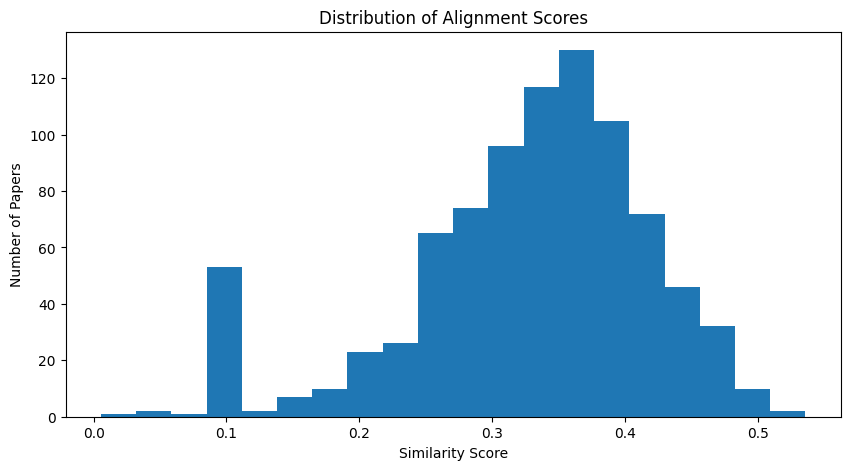

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df["alignment_score"], bins=20)
plt.title("Distribution of Alignment Scores")
plt.xlabel("Similarity Score")
plt.ylabel("Number of Papers")
plt.show()

In [12]:
yearly_scores = df.groupby("year")["alignment_score"].agg(
    mean="mean",
    median="median",
    count="count",
    std="std"
).reset_index()

yearly_scores

,year,mean,median,count,std
0,2012,0.325082,0.325082,1,NaN
1,2013,0.329460,0.343904,40,0.120585
2,2014,0.228267,0.110379,89,0.129410
3,2015,0.346987,0.354844,51,0.067389
4,2016,0.347634,0.340763,45,0.069352
5,2017,0.343486,0.346727,43,0.072964
6,2018,0.369643,0.372845,34,0.063732
7,2019,0.352754,0.365083,55,0.071133
8,2020,0.337710,0.339367,74,0.077190
9,2021,0.342617,0.348362,107,0.078221


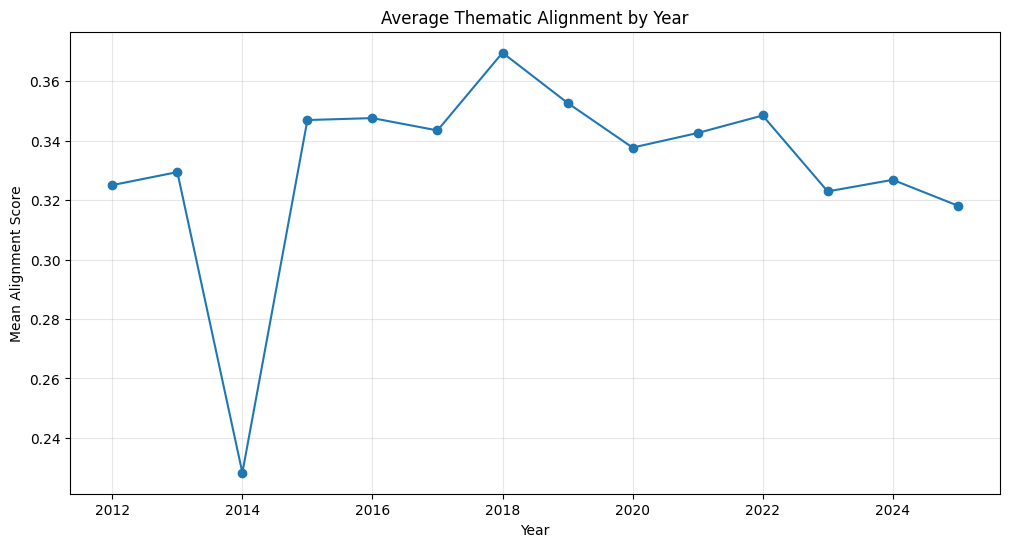

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(yearly_scores["year"], yearly_scores["mean"], marker="o")
plt.title("Average Thematic Alignment by Year")
plt.xlabel("Year")
plt.ylabel("Mean Alignment Score")
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
low = df.sort_values("alignment_score").head(10)
low[["year","title","alignment_score"]]

,year,title,alignment_score
48,2014,Walker's Cancellation Theorem,0.005457
22,2013,Idempotent generated algebras and Boolean powe...,0.041144
416,2020,Erratum: “BLiMP: The Benchmark of Linguistic M...,0.045693
28,2013,The Benefits of a Model of Annotation,0.076065
706,2023,Removing Backdoors in Pre-trained Models by Re...,0.085159
530,2021,Erratum: Measuring and Improving Consistency i...,0.091922
449,2021,"Retrieve Fast, Rerank Smart: Cooperative and J...",0.101739
79,2014,On fuzzification of topological categories,0.110379
80,2014,Laterally complete and projective hulls of sem...,0.110379
81,2014,A Complete Calculus of Monotone and Antitone H...,0.110379


In [15]:
high = df.sort_values("alignment_score", ascending=False).head(10)
high[["year","title","alignment_score"]]

,year,title,alignment_score
752,2024,The Thai Discourse Treebank: Annotating and Cl...,0.535789
452,2021,An Error Analysis Framework for Shallow Surfac...,0.510715
371,2020,Unsupervised Discourse Constituency Parsing Us...,0.505973
512,2021,Text-based NP Enrichment,0.504872
152,2015,One Vector is Not Enough: Entity-Augmented Dis...,0.503060
178,2016,"Many Languages, One Parser",0.502632
31,2013,Joint Morphological and Syntactic Analysis for...,0.497887
608,2022,The Emergence of Argument Structure in Artific...,0.495733
807,2024,Benchmarking Linguistic Diversity of Large Lan...,0.492473
366,2020,TyDi QA: A Benchmark for Information-Seeking Q...,0.491257


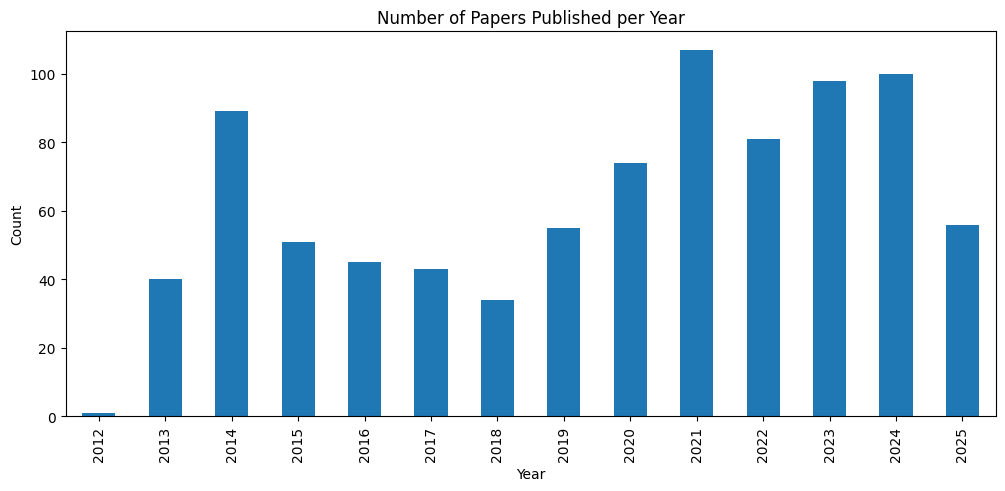

In [16]:
papers_per_year = df["year"].value_counts().sort_index()

plt.figure(figsize=(12,5))
papers_per_year.plot(kind="bar")
plt.title("Number of Papers Published per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

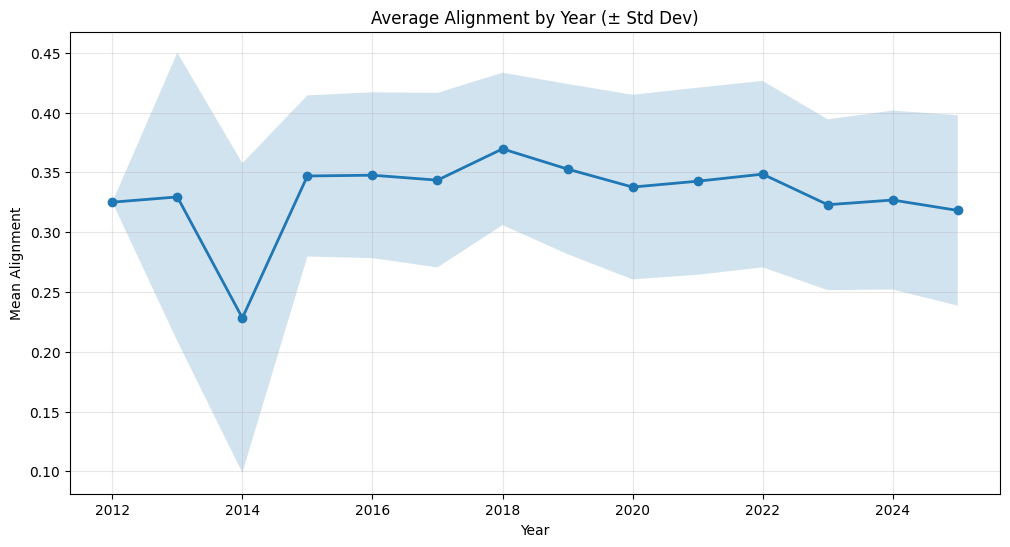

In [17]:
plt.figure(figsize=(12,6))
plt.plot(yearly_scores["year"], yearly_scores["mean"], marker="o", linewidth=2)
plt.fill_between(
    yearly_scores["year"],
    yearly_scores["mean"] - yearly_scores["std"].fillna(0),
    yearly_scores["mean"] + yearly_scores["std"].fillna(0),
    alpha=0.2
)
plt.title("Average Alignment by Year (± Std Dev)")
plt.xlabel("Year")
plt.ylabel("Mean Alignment")
plt.grid(alpha=0.3)
plt.show()

In [18]:
df.sort_values("alignment_score", ascending=False)[["year","title","alignment_score"]].head(10)

,year,title,alignment_score
752,2024,The Thai Discourse Treebank: Annotating and Cl...,0.535789
452,2021,An Error Analysis Framework for Shallow Surfac...,0.510715
371,2020,Unsupervised Discourse Constituency Parsing Us...,0.505973
512,2021,Text-based NP Enrichment,0.504872
152,2015,One Vector is Not Enough: Entity-Augmented Dis...,0.503060
178,2016,"Many Languages, One Parser",0.502632
31,2013,Joint Morphological and Syntactic Analysis for...,0.497887
608,2022,The Emergence of Argument Structure in Artific...,0.495733
807,2024,Benchmarking Linguistic Diversity of Large Lan...,0.492473
366,2020,TyDi QA: A Benchmark for Information-Seeking Q...,0.491257


In [19]:
df.sort_values("alignment_score")[["year","title","alignment_score"]].head(10)

,year,title,alignment_score
48,2014,Walker's Cancellation Theorem,0.005457
22,2013,Idempotent generated algebras and Boolean powe...,0.041144
416,2020,Erratum: “BLiMP: The Benchmark of Linguistic M...,0.045693
28,2013,The Benefits of a Model of Annotation,0.076065
706,2023,Removing Backdoors in Pre-trained Models by Re...,0.085159
530,2021,Erratum: Measuring and Improving Consistency i...,0.091922
449,2021,"Retrieve Fast, Rerank Smart: Cooperative and J...",0.101739
79,2014,On fuzzification of topological categories,0.110379
80,2014,Laterally complete and projective hulls of sem...,0.110379
81,2014,A Complete Calculus of Monotone and Antitone H...,0.110379


In [20]:
yearly_scores["count"].corr(yearly_scores["mean"])

np.float64(-0.29113067067315423)

In [21]:
## Representation

In [22]:
papers_per_year = df["year"].value_counts().sort_index()
papers_per_year

year
2012      1
2013     40
2014     89
2015     51
2016     45
2017     43
2018     34
2019     55
2020     74
2021    107
2022     81
2023     98
2024    100
2025     56
Name: count, dtype: int64

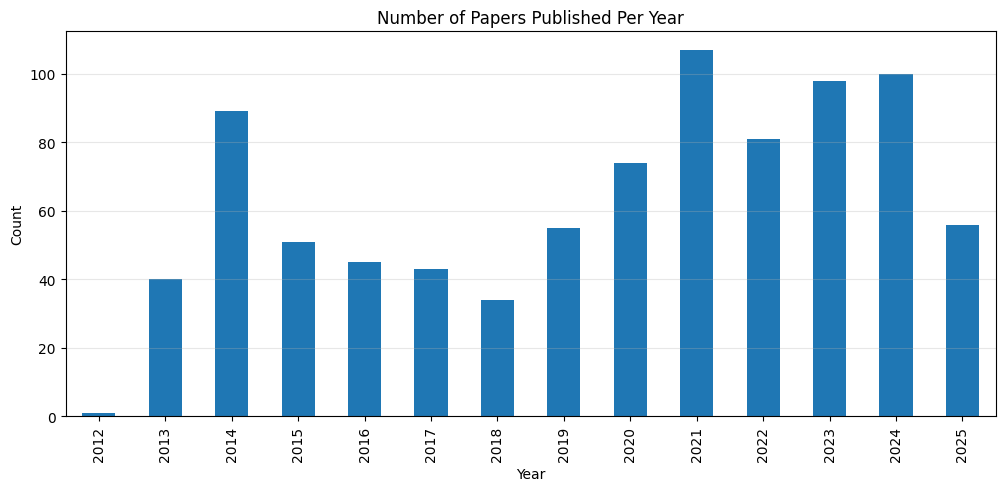

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
papers_per_year.plot(kind="bar")
plt.title("Number of Papers Published Per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.show()

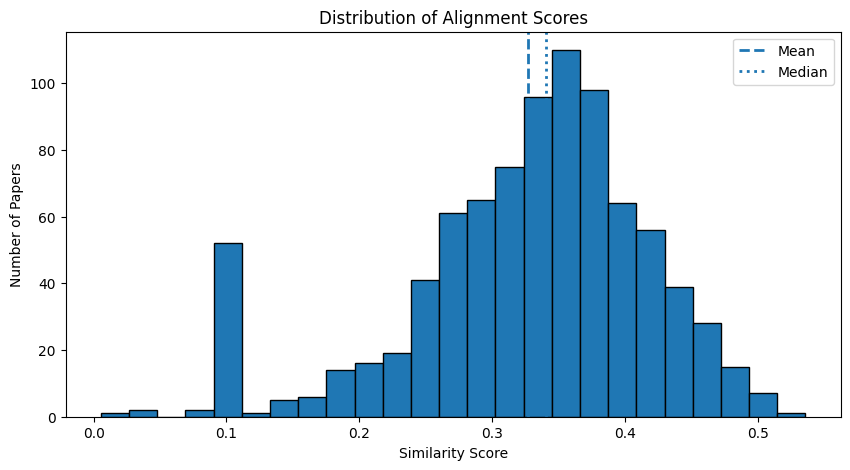

In [24]:
plt.figure(figsize=(10,5))
plt.hist(df["alignment_score"], bins=25, edgecolor="black")
plt.axvline(df["alignment_score"].mean(), linestyle="--", linewidth=2, label="Mean")
plt.axvline(df["alignment_score"].median(), linestyle=":", linewidth=2, label="Median")
plt.title("Distribution of Alignment Scores")
plt.xlabel("Similarity Score")
plt.ylabel("Number of Papers")
plt.legend()
plt.show()

In [25]:
low_papers = df.sort_values("alignment_score").head(10)
low_papers[["year", "title", "alignment_score"]]

,year,title,alignment_score
48,2014,Walker's Cancellation Theorem,0.005457
22,2013,Idempotent generated algebras and Boolean powe...,0.041144
416,2020,Erratum: “BLiMP: The Benchmark of Linguistic M...,0.045693
28,2013,The Benefits of a Model of Annotation,0.076065
706,2023,Removing Backdoors in Pre-trained Models by Re...,0.085159
530,2021,Erratum: Measuring and Improving Consistency i...,0.091922
449,2021,"Retrieve Fast, Rerank Smart: Cooperative and J...",0.101739
79,2014,On fuzzification of topological categories,0.110379
80,2014,Laterally complete and projective hulls of sem...,0.110379
81,2014,A Complete Calculus of Monotone and Antitone H...,0.110379


In [26]:
high_papers = df.sort_values("alignment_score", ascending=False).head(10)
high_papers[["year", "title", "alignment_score"]]

,year,title,alignment_score
752,2024,The Thai Discourse Treebank: Annotating and Cl...,0.535789
452,2021,An Error Analysis Framework for Shallow Surfac...,0.510715
371,2020,Unsupervised Discourse Constituency Parsing Us...,0.505973
512,2021,Text-based NP Enrichment,0.504872
152,2015,One Vector is Not Enough: Entity-Augmented Dis...,0.503060
178,2016,"Many Languages, One Parser",0.502632
31,2013,Joint Morphological and Syntactic Analysis for...,0.497887
608,2022,The Emergence of Argument Structure in Artific...,0.495733
807,2024,Benchmarking Linguistic Diversity of Large Lan...,0.492473
366,2020,TyDi QA: A Benchmark for Information-Seeking Q...,0.491257


<Figure size 1400x600 with 0 Axes>

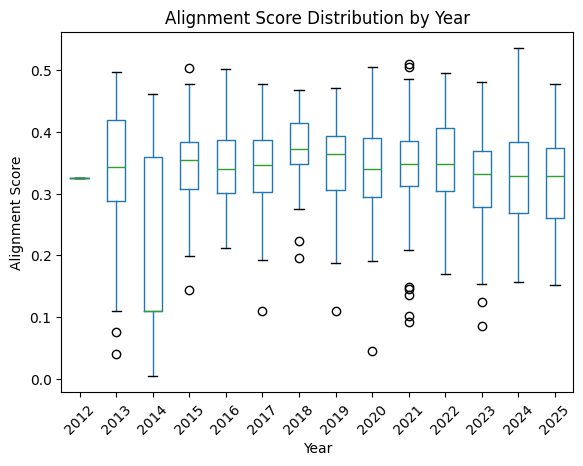

In [27]:
plt.figure(figsize=(14,6))
df.boxplot(column="alignment_score", by="year", grid=False, rot=45)
plt.title("Alignment Score Distribution by Year")
plt.suptitle("")
plt.xlabel("Year")
plt.ylabel("Alignment Score")
plt.show()

In [28]:
merged = yearly_scores.merge(
    papers_per_year.rename("count"),
    left_on="year",
    right_index=True
)

In [29]:
print(merged.columns)

Index(['year', 'mean', 'median', 'count_x', 'std', 'count_y'], dtype='object')


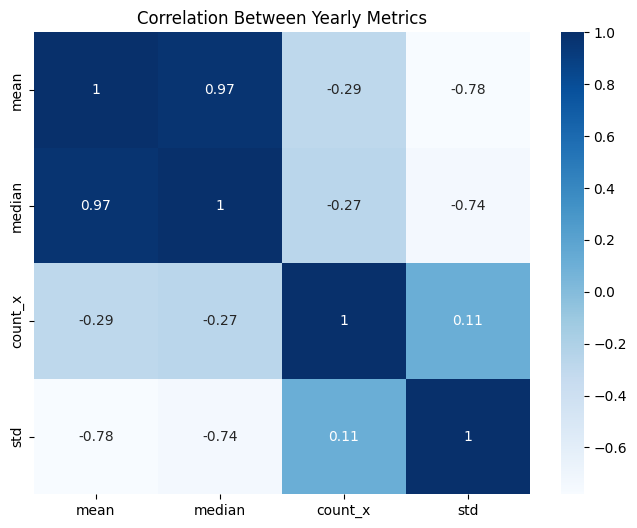

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    merged[["mean", "median", "count_x", "std"]].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Between Yearly Metrics")
plt.show()

In [31]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

pca_result = pca.fit_transform(article_embeddings)

df["pca1"] = pca_result[:, 0]
df["pca2"] = pca_result[:, 1]

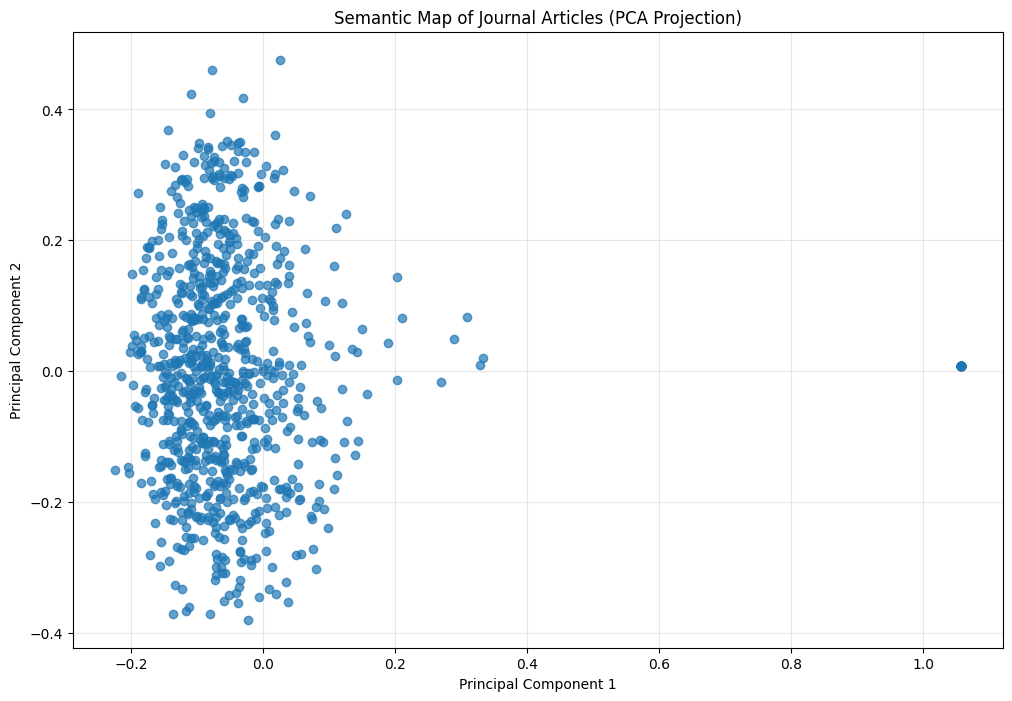

In [32]:
plt.figure(figsize=(12,8))

plt.scatter(
    df["pca1"],
    df["pca2"],
    alpha=0.7
)

plt.title("Semantic Map of Journal Articles (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(alpha=0.3)
plt.show()

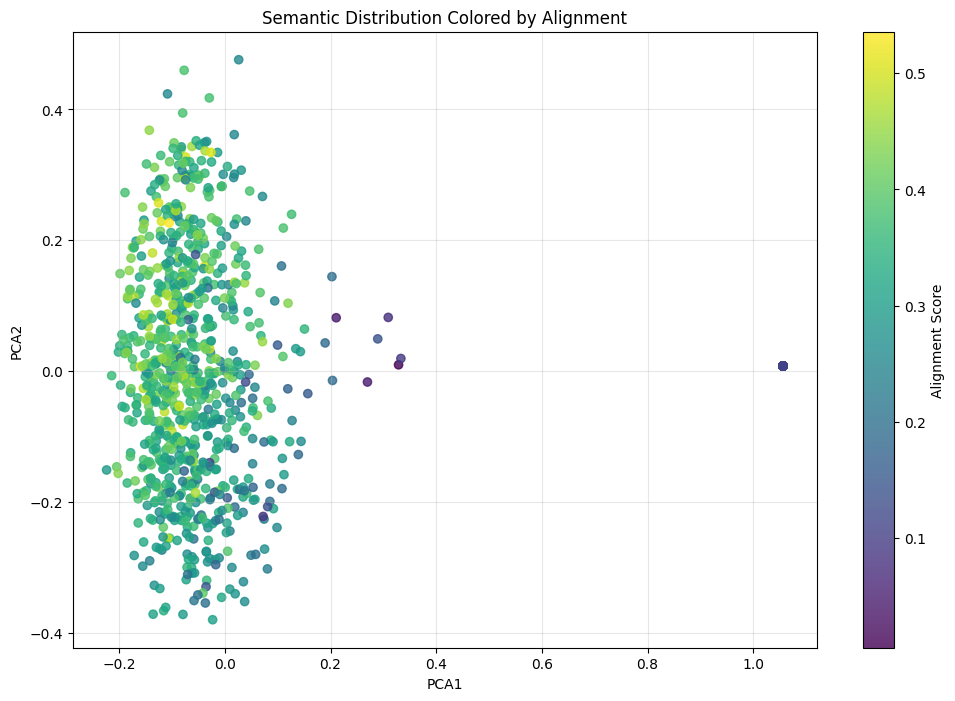

In [33]:
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    df["pca1"],
    df["pca2"],
    c=df["alignment_score"],
    alpha=0.8
)

plt.colorbar(scatter, label="Alignment Score")

plt.title("Semantic Distribution Colored by Alignment")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.grid(alpha=0.3)
plt.show()

In [34]:
# Methodology

## Data Source
## The dataset was collected using the Semantic Scholar API.  
## The selected journal was *Transactions of the Association for Computational Linguistics (TACL)*.

## Textual Inputs
## For each publication, the article abstract was used as the textual representation.  
## The journal's aims and scope statement was used as the thematic reference document.

## NLP Representation
## Texts were converted into dense semantic embeddings using the Sentence-BERT model:

## `all-MiniLM-L6-v2`

## Similarity Measure
## Cosine similarity was computed between each article embedding and the journal scope embedding.

## Objective
## The objective is to evaluate how strongly published articles align with the stated thematic focus of the journal.

In [35]:
## PHASE 2


In [36]:
!pip install keybert

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [37]:
from keybert import KeyBERT

kw_model = KeyBERT()

keywords = kw_model.extract_keywords(
    journal_scope,
    keyphrase_ngram_range=(1,2),
    stop_words="english",
    top_n=8
)

keywords

[('computational linguistics', 0.6935),
 ('nlp language', 0.5999),
 ('multilingual nlp', 0.5603),
 ('language generation', 0.542),
 ('linguistics', 0.5384),
 ('language processing', 0.5351),
 ('natural language', 0.5305),
 ('linguistics natural', 0.5259)]

In [38]:
labels = [k[0] for k in keywords]
labels

['computational linguistics',
 'nlp language',
 'multilingual nlp',
 'language generation',
 'linguistics',
 'language processing',
 'natural language',
 'linguistics natural']

In [39]:
from transformers import pipeline

classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

Device set to use mps:0


In [40]:
sample_text = df["abstract"].dropna().iloc[0]

classifier(sample_text, labels)

{'sequence': 'Supervised learning methods and LDA based topic model have been successfully applied in the field of multi-document summarization. In this paper, we propose a novel supervised approach that can incorporate rich sentence features into Bayesian topic models in a principled way, thus taking advantages of both topic model and feature based supervised learning methods. Experimental results on DUC2007, TAC2008 and TAC2009 demonstrate the effectiveness of our approach.',
 'labels': ['linguistics natural',
  'nlp language',
  'language processing',
  'multilingual nlp',
  'natural language',
  'computational linguistics',
  'language generation',
  'linguistics'],
 'scores': [0.18085835874080658,
  0.17568475008010864,
  0.15342773497104645,
  0.1298477202653885,
  0.11653927713632584,
  0.10505614429712296,
  0.07239113003015518,
  0.06619488447904587]}

In [41]:
labels

['computational linguistics',
 'nlp language',
 'multilingual nlp',
 'language generation',
 'linguistics',
 'language processing',
 'natural language',
 'linguistics natural']

In [42]:
clean_labels = [
    "Computational Linguistics",
    "Natural Language Processing",
    "Language Processing",
    "Multilingual NLP",
    "Language Generation",
    "Linguistics"
]